# PINN Problem Setup — Single-File Configuration

This notebook explains and demonstrates how the governing equations, boundary conditions, and initial conditions are centralised in **one file**: `src/problem_definition.py`.

## Architecture

```
src/problem_definition.py   ← ONLY THIS FILE CHANGES per problem
        │
        │  exports  ACTIVE_PROBLEM (ProblemSpec)
        ▼
src/loss.py                 ← reads ACTIVE_PROBLEM, no hardcoded equations
src/trainer.py              ← calls loss.py, no problem-specific code
main.py                     ← injects runtime params, calls Trainer(net)
```

### Key dataclasses

| Class | Purpose |
|---|---|
| `DomainSpec` | x₁, x₃ (and optional t) bounds for collocation sampling |
| `BoundaryCondition` | name + residual callable + weight |
| `InitialCondition` | name + residual callable + weight *(optional)* |
| `ProblemSpec` | PDE fn + list of BCs + optional list of ICs + runtime params |

---

> **Rule**: If you change the physics, only edit `src/problem_definition.py`.
> `loss.py`, `trainer.py`, and `main.py` never need to change.

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  


import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

d:\
PyTorch: 2.12.0+cpu
CUDA available: False


## 1 — Inspect the Current Problem Definition (PZT-4)

In [2]:
from src.problem_definition import ACTIVE_PROBLEM

print("Problem :", ACTIVE_PROBLEM.name)
print("Domain  :")
print(f"  x1 ∈ {ACTIVE_PROBLEM.domain.x1_range}")
print(f"  x3 ∈ {ACTIVE_PROBLEM.domain.x3_range}")
print(f"  t  ∈ {ACTIVE_PROBLEM.domain.t_range}  (None = steady/quasi-static)")
print("\nBoundary conditions:")
for bc in ACTIVE_PROBLEM.boundary_conditions:
    print(f"  [{bc.name}]  weight={bc.weight}")
print("\nInitial conditions:")
if ACTIVE_PROBLEM.has_initial_conditions:
    for ic in ACTIVE_PROBLEM.initial_conditions:
        print(f"  [{ic.name}]  weight={ic.weight}")
else:
    print("  None (quasi-static problem — no ICs needed)")
print("\nRuntime params:", list(ACTIVE_PROBLEM.params.keys()) if ACTIVE_PROBLEM.params else "None")

Problem : Triclinic Piezoelectric Interface — Modal Expansion (7 Partial Waves)
Domain  :
  x1 ∈ (0.0, 10.0)
  x3 ∈ (0.0, 5.0)
  t  ∈ (0.0, 2.0)  (None = steady/quasi-static)

Boundary conditions:
  [bc_u1_sum]  weight=10.0
  [bc_u2_sum]  weight=10.0
  [bc_u3_sum]  weight=10.0
  [bc_T31_sum]  weight=10.0
  [bc_T32_sum]  weight=10.0
  [bc_phi_sum]  weight=10.0

Initial conditions:
  None (quasi-static problem — no ICs needed)

Runtime params: None


## 2 — Define a Different Problem in One Cell

We define a simple **2-D Poisson / Laplace problem** purely to show how the single-file pattern works:

$$-\nabla^2 u = f(x_1, x_3), \quad (x_1,x_3)\in[0,1]^2$$

Boundary conditions (Dirichlet zero on all sides):
$$u = 0 \text{ on } \partial\Omega$$

Manufactured solution: $u^* = \sin(\pi x_1)\sin(\pi x_3)$, 
so $f = 2\pi^2 \sin(\pi x_1)\sin(\pi x_3)$.

**No initial condition** — this is a steady (time-independent) problem.

In [3]:
import math
import torch
import torch.nn as nn
from torch import Tensor
from src.problem_definition import (
    BoundaryCondition, InitialCondition, DomainSpec, ProblemSpec
)

# ── Tiny network for the Poisson problem ─────────────────────────────────────
class PoissonNet(nn.Module):
    """Inputs: (x1, x3)  →  Output: u (scalar)"""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x1: Tensor, x3: Tensor, t: Tensor = None) -> Tensor:
        # t is ignored — steady problem
        inp = torch.cat([x1, x3], dim=-1)
        return self.net(inp)


# ── Autograd helper ──────────────────────────────────────────────────────────
def _grad(out: Tensor, inp: Tensor) -> Tensor:
    return torch.autograd.grad(
        out, inp, grad_outputs=torch.ones_like(out),
        create_graph=True, retain_graph=True
    )[0]


# ── Governing equation: -∇²u = f ─────────────────────────────────────────────
def poisson_pde_fn(net, x1: Tensor, x3: Tensor, t: Tensor):
    u = net(x1, x3)                          # (N,1)
    u_x1  = _grad(u, x1)
    u_x3  = _grad(u, x3)
    u_x1x1 = _grad(u_x1, x1)
    u_x3x3 = _grad(u_x3, x3)
    # Manufactured source  f = 2π²sin(πx1)sin(πx3)
    pi = math.pi
    f = 2 * pi**2 * torch.sin(pi * x1) * torch.sin(pi * x3)
    residual = -(u_x1x1 + u_x3x3) - f       # should be 0
    return [residual]


# ── Boundary condition: u = 0 on all four sides ───────────────────────────────
def dirichlet_bc(net, N: int, device, dtype, **_):
    """Sample points on all four edges, enforce u = 0."""
    n = N // 4
    ones   = torch.ones (n, 1, device=device, dtype=dtype)
    zeros  = torch.zeros(n, 1, device=device, dtype=dtype)
    coords = torch.rand (n, 1, device=device, dtype=dtype)  # ∈ [0,1]

    # bottom: x3=0, top: x3=1, left: x1=0, right: x1=1
    pts = [
        (coords, zeros),     # bottom edge
        (coords, ones),      # top edge
        (zeros,  coords),    # left edge
        (ones,   coords),    # right edge
    ]
    residuals = []
    for x1e, x3e in pts:
        u = net(x1e, x3e)
        residuals.append(u)      # target = 0

    return torch.cat(residuals, dim=0)


# ── Build the Poisson ProblemSpec ─────────────────────────────────────────────
poisson_problem = ProblemSpec(
    name="2D Poisson (Manufactured Solution, Dirichlet BC)",
    domain=DomainSpec(
        x1_range=(0.0, 1.0),
        x3_range=(0.0, 1.0),
        t_range=None,           # ← steady: no time axis, no ICs
    ),
    pde_fn=poisson_pde_fn,
    boundary_conditions=[
        BoundaryCondition("dirichlet_zero", dirichlet_bc, weight=10.0),
    ],
    initial_conditions=None,    # ← no ICs for steady problem
)

print("Problem :", poisson_problem.name)
print("Has ICs :", poisson_problem.has_initial_conditions)
print("Is time-dependent:", poisson_problem.is_time_dependent)
print("BCs     :", [bc.name for bc in poisson_problem.boundary_conditions])

Problem : 2D Poisson (Manufactured Solution, Dirichlet BC)
Has ICs : False
Is time-dependent: False
BCs     : ['dirichlet_zero']


## 3 — Train the Poisson PINN Using the Generic Loss

We pass `problem=poisson_problem` directly to `pinn_loss` — **no changes to `loss.py`**.

In [4]:

import importlib
import src.loss
importlib.reload(src.loss)
from src.loss import pinn_loss

device = torch.device("cpu")
dtype  = torch.float32   # float32 is fine for this demo

net_poisson = PoissonNet(hidden=64).to(device=device, dtype=dtype)
optimiser   = torch.optim.Adam(net_poisson.parameters(), lr=1e-3)

history = []
N_ITER  = 3000

for step in range(1, N_ITER + 1):
    optimiser.zero_grad()
    loss, comps = pinn_loss(
        net_poisson,
        N_int=2000, N_bc=400, N_ic=0,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=0.0,
        problem=poisson_problem,    # ← pass the custom problem, no code change needed
    )
    loss.backward()
    optimiser.step()
    history.append(float(comps["total"]))

    if step % 500 == 0:
        print(f"Step {step:4d}  loss={float(comps['total']):.4e}  "
              f"pde={float(comps['pde']):.4e}  "
              f"bc={float(comps['bc_total']):.4e}")

print("\nTraining complete.")

Step  500  loss=1.3632e-01  pde=2.7319e-02  bc=1.0900e-01
Step 1000  loss=4.2424e-02  pde=6.1244e-03  bc=3.6300e-02
Step 1500  loss=1.4478e-02  pde=5.3619e-03  bc=9.1159e-03
Step 2000  loss=4.6587e-03  pde=2.7739e-03  bc=1.8848e-03
Step 2500  loss=1.8299e-03  pde=1.4066e-03  bc=4.2331e-04
Step 3000  loss=7.6234e-03  pde=6.9516e-03  bc=6.7187e-04

Training complete.


## 4 — Evaluate Against the Manufactured Solution

L₂ error: 1.7229e-02


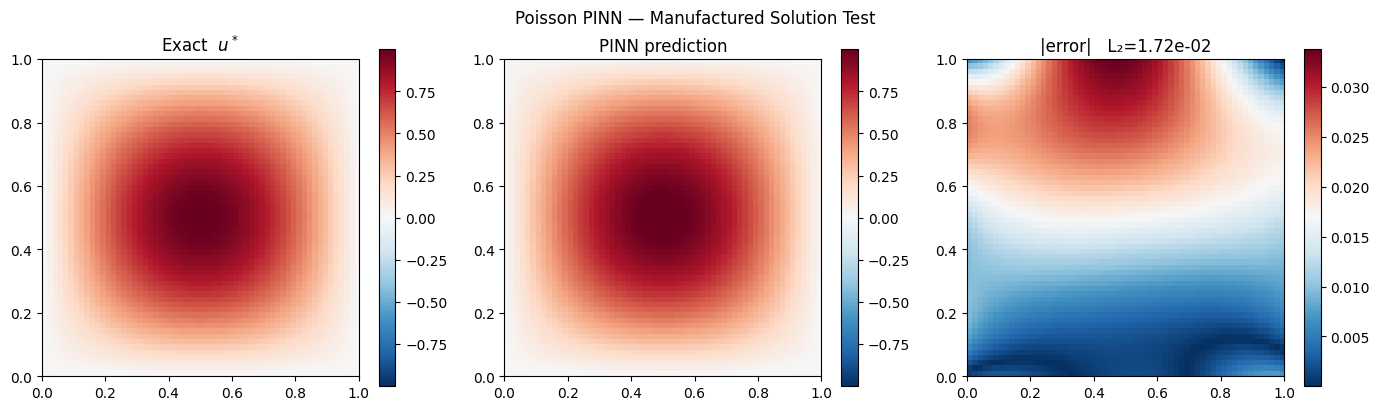

In [5]:
import numpy as np
import matplotlib.pyplot as plt

pi = math.pi
N  = 60
x1v = np.linspace(0, 1, N)
x3v = np.linspace(0, 1, N)
X1, X3 = np.meshgrid(x1v, x3v)

# Exact solution
U_exact = np.sin(pi * X1) * np.sin(pi * X3)

# PINN prediction
with torch.no_grad():
    x1t = torch.tensor(X1.ravel(), dtype=dtype).unsqueeze(1)
    x3t = torch.tensor(X3.ravel(), dtype=dtype).unsqueeze(1)
    U_pred = net_poisson(x1t, x3t).numpy().reshape(N, N)

# Error
L2_err = np.sqrt(np.mean((U_pred - U_exact)**2))
print(f"L₂ error: {L2_err:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(origin="lower", extent=[0,1,0,1], aspect="equal", cmap="RdBu_r")

vmax = U_exact.max()
im0 = axes[0].imshow(U_exact, vmin=-vmax, vmax=vmax, **kw)
axes[0].set_title("Exact  $u^*$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred,  vmin=-vmax, vmax=vmax, **kw)
axes[1].set_title("PINN prediction")
plt.colorbar(im1, ax=axes[1])

err = np.abs(U_pred - U_exact)
im2 = axes[2].imshow(err, **kw)
axes[2].set_title(f"|error|   L₂={L2_err:.2e}")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Poisson PINN — Manufactured Solution Test")
plt.tight_layout()
plt.show()

## 5 — Example: Problem WITH Initial Conditions

The same pattern supports **time-dependent problems** with ICs.  
Here we define a 1-D heat equation:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x_1^2}, \quad x_1\in[0,1],\ t\in[0,1]$$

BCs: $u(0,t)=u(1,t)=0$  
IC: $u(x_1,0) = \sin(\pi x_1)$  
Exact: $u^* = e^{-\alpha\pi^2 t}\sin(\pi x_1)$

> Setting `initial_conditions=[InitialCondition(...)]` automatically activates the IC loss term — no changes to `loss.py`.

In [6]:
ALPHA = 0.1   # thermal diffusivity

# ── Network: inputs (x1, t)  →  output u ────────────────────────────────────
class HeatNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x1: Tensor, x3: Tensor, t: Tensor) -> Tensor:
        # x3 is unused; t is the time coordinate
        inp = torch.cat([x1, t], dim=-1)
        return self.net(inp)


# ── PDE residual: du/dt - α d²u/dx1² = 0 ─────────────────────────────────────
def heat_pde_fn(net, x1: Tensor, x3: Tensor, t: Tensor):
    # NOTE: t must have requires_grad=True for du/dt
    t.requires_grad_(True)
    u = net(x1, x3, t)
    u_t   = _grad(u, t)
    u_x1  = _grad(u, x1)
    u_x1x1 = _grad(u_x1, x1)
    residual = u_t - ALPHA * u_x1x1
    return [residual]


# ── Boundary conditions: u(0,t) = u(1,t) = 0 ─────────────────────────────────
def heat_bc(net, N: int, device, dtype, **_):
    t_rand = torch.rand(N, 1, device=device, dtype=dtype)    # t ~ U[0,1]
    zeros  = torch.zeros(N, 1, device=device, dtype=dtype)
    ones   = torch.ones (N, 1, device=device, dtype=dtype)
    x3_dummy = zeros
    u_left  = net(zeros, x3_dummy, t_rand)   # u(0,t)
    u_right = net(ones,  x3_dummy, t_rand)   # u(1,t)
    return torch.cat([u_left, u_right], dim=0)


# ── Initial condition: u(x1,0) = sin(π x1) ───────────────────────────────────
def heat_ic(net, N: int, device, dtype, **_):
    x1_rand = torch.rand(N, 1, device=device, dtype=dtype)   # x1 ~ U[0,1]
    t_zero  = torch.zeros(N, 1, device=device, dtype=dtype)
    x3_dummy = t_zero
    u_pred = net(x1_rand, x3_dummy, t_zero)
    u_exact = torch.sin(math.pi * x1_rand)
    return u_pred - u_exact


# ── Assemble the heat problem ─────────────────────────────────────────────────
heat_problem = ProblemSpec(
    name="1D Heat Equation (with Initial Condition)",
    domain=DomainSpec(
        x1_range=(0.0, 1.0),
        x3_range=(0.0, 1.0),   # x3 unused but required by DomainSpec
        t_range=(0.0, 1.0),    # ← time-dependent
    ),
    pde_fn=heat_pde_fn,
    boundary_conditions=[
        BoundaryCondition("dirichlet_zero", heat_bc, weight=10.0),
    ],
    initial_conditions=[             # ← ICs automatically used in loss
        InitialCondition("u_t0", heat_ic, weight=10.0),
    ],
)

print("Problem :", heat_problem.name)
print("Has ICs :", heat_problem.has_initial_conditions)
print("Is time-dependent:", heat_problem.is_time_dependent)

Problem : 1D Heat Equation (with Initial Condition)
Has ICs : True
Is time-dependent: True


In [7]:
net_heat  = HeatNet(hidden=64).to(device=device, dtype=dtype)
opt_heat  = torch.optim.Adam(net_heat.parameters(), lr=1e-3)

hist_heat = []
for step in range(1, 4001):
    opt_heat.zero_grad()
    loss, comps = pinn_loss(
        net_heat,
        N_int=2000, N_bc=400, N_ic=400,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=1.0,
        problem=heat_problem,     # ← different problem, same loss.py
    )
    loss.backward()
    opt_heat.step()
    hist_heat.append(float(comps["total"]))

    if step % 1000 == 0:
        print(f"Step {step:4d}  total={float(comps['total']):.4e}  "
              f"pde={float(comps['pde']):.4e}  "
              f"bc={float(comps['bc_total']):.4e}  "
              f"ic={float(comps['ic_total']):.4e}")

print("Done.")

Step 1000  total=1.1980e-03  pde=6.3364e-04  bc=2.8494e-04  ic=2.7937e-04
Step 2000  total=2.3075e-04  pde=1.9316e-04  bc=1.6211e-05  ic=2.1379e-05
Step 3000  total=2.9773e-04  pde=1.3348e-04  bc=7.6724e-05  ic=8.7522e-05
Step 4000  total=1.1995e-03  pde=1.1101e-04  bc=5.4542e-04  ic=5.4309e-04
Done.


Heat equation L₂ error: 6.7386e-03


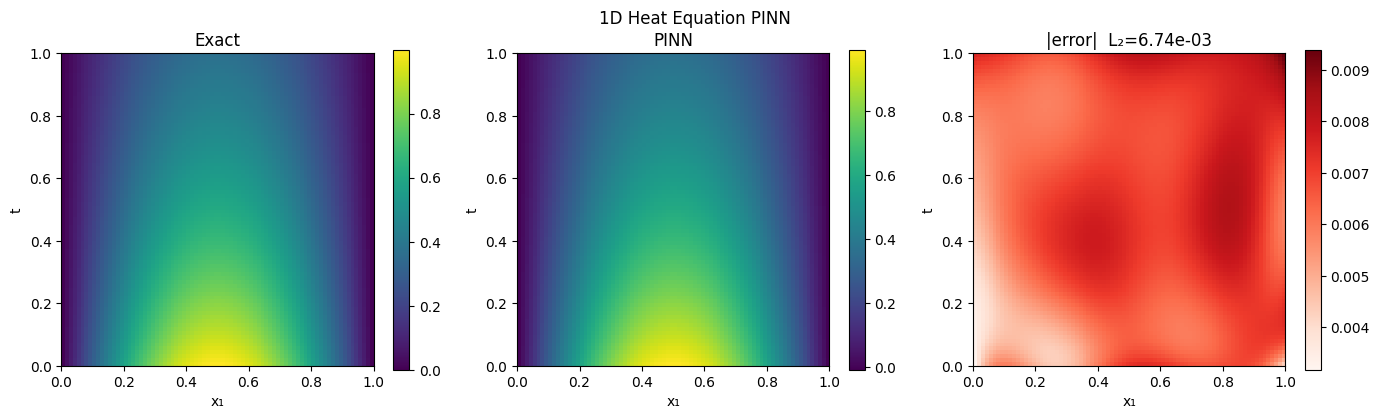

In [8]:
# ── Evaluate against exact solution ──────────────────────────────────────────
N = 80
x1v = np.linspace(0, 1, N)
tv  = np.linspace(0, 1, N)
X1h, Th = np.meshgrid(x1v, tv)

U_exact_heat = np.exp(-ALPHA * pi**2 * Th) * np.sin(pi * X1h)

with torch.no_grad():
    x1t = torch.tensor(X1h.ravel(), dtype=dtype).unsqueeze(1)
    tt  = torch.tensor(Th.ravel(),  dtype=dtype).unsqueeze(1)
    xt3 = torch.zeros_like(x1t)
    U_pred_heat = net_heat(x1t, xt3, tt).numpy().reshape(N, N)

L2_heat = np.sqrt(np.mean((U_pred_heat - U_exact_heat)**2))
print(f"Heat equation L₂ error: {L2_heat:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw2 = dict(origin="lower", extent=[0,1,0,1], aspect="equal", cmap="viridis")

im0 = axes[0].imshow(U_exact_heat, **kw2)
axes[0].set(title="Exact", xlabel="x₁", ylabel="t")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred_heat,  **kw2)
axes[1].set(title="PINN", xlabel="x₁", ylabel="t")
plt.colorbar(im1, ax=axes[1])

err2 = np.abs(U_pred_heat - U_exact_heat)
im2 = axes[2].imshow(err2, origin="lower", extent=[0,1,0,1], aspect="equal", cmap="Reds")
axes[2].set(title=f"|error|  L₂={L2_heat:.2e}", xlabel="x₁", ylabel="t")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("1D Heat Equation PINN")
plt.tight_layout()
plt.show()

## 6 — Loss Convergence

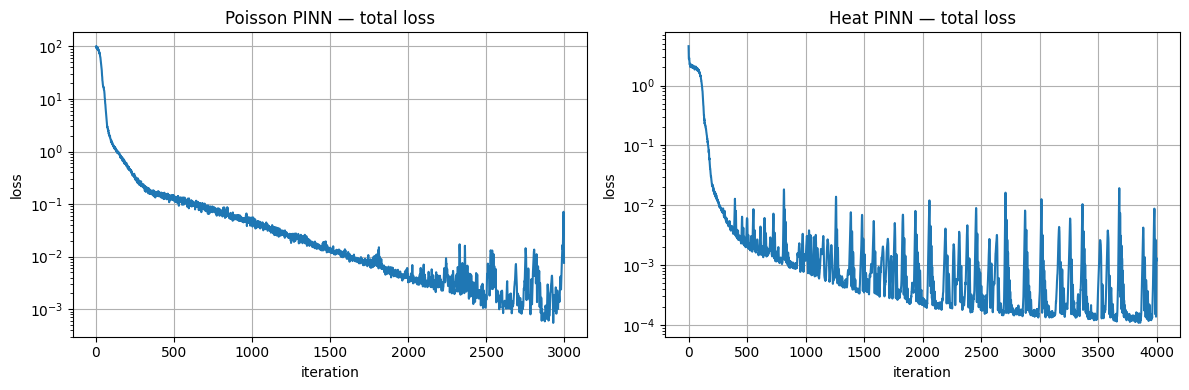

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history)
axes[0].set(title="Poisson PINN — total loss", xlabel="iteration", ylabel="loss")
axes[0].grid(True)

axes[1].semilogy(hist_heat)
axes[1].set(title="Heat PINN — total loss", xlabel="iteration", ylabel="loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()